# Experiment 05 — Threshold Optimization vs Adaptive Cost-Sensitive Loss

## Objective

Test whether the Adaptive Cost-Sensitive Loss provides value beyond simply
changing the classification threshold of a standard model.

### Main Research Question

> Does adaptive cost-sensitive training improve business-cost performance
> beyond standard training + post-hoc threshold optimization?

### Models Compared

1. Random Forest + validation threshold optimization
2. MLP + BCE + validation threshold optimization
3. MLP + class-weighted BCE + validation threshold optimization
4. MLP + Adaptive Cost-Sensitive Loss + validation threshold optimization

### Important Experimental Rule

The original project test set is kept completely untouched during model
selection and threshold selection.

The original training set is divided into:

- Training set
- Validation set

Thresholds are selected only using the validation set.

The test set is evaluated only after all decisions have been made.

### Business Cost

For consistency with the original project:

    Total Cost = 10 × False Negatives + 1 × False Positives

This is a project-defined cost assumption, not an actual OneBanc cost matrix.

In [2]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# Locate project root
# ============================================================

CURRENT_DIR = os.path.abspath(os.getcwd())

# If notebook is being run from notebooks/
if os.path.basename(CURRENT_DIR).lower() == "notebooks":
    PROJECT_ROOT = os.path.dirname(CURRENT_DIR)
else:
    # Otherwise assume current directory is the project root
    PROJECT_ROOT = CURRENT_DIR

print("Project root:", PROJECT_ROOT)

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ============================================================
# PyTorch
# ============================================================

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

# ============================================================
# Scikit-learn
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ============================================================
# Existing project modules
# ============================================================

from src.data.load_data import load_creditcard_data
from src.models.mlp import MLPClassifier
from src.losses.adaptive_cost_sensitive import AdaptiveCostSensitiveLoss

# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

Project root: C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss
PyTorch version: 2.14.1+cpu
Device: cpu


In [3]:
# ============================================================
# Verify important project files
# ============================================================

required_paths = [
    os.path.join(PROJECT_ROOT, "src"),
    os.path.join(PROJECT_ROOT, "src", "data"),
    os.path.join(PROJECT_ROOT, "src", "models"),
    os.path.join(PROJECT_ROOT, "src", "losses"),
    os.path.join(PROJECT_ROOT, "data"),
    os.path.join(PROJECT_ROOT, "data", "raw"),
]

print("Checking project structure...\n")

for path in required_paths:
    print(
        f"{'OK' if os.path.exists(path) else 'MISSING':8s} "
        f"{path}"
    )

print("\nChecking creditcard.csv...")

data_file = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw",
    "creditcard.csv"
)

if os.path.exists(data_file):
    print("OK:", data_file)
else:
    print("MISSING:", data_file)
    print("\nPlace creditcard.csv inside:")
    print(os.path.join(PROJECT_ROOT, "data", "raw"))

Checking project structure...

OK       C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss\src
OK       C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss\src\data
OK       C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss\src\models
OK       C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss\src\losses
OK       C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss\data
OK       C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss\data\raw

Checking creditcard.csv...
OK: C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss\data\raw\creditcard.csv


In [4]:
# ============================================================
# Load original project train/test split
# ============================================================

X_train_full, y_train_full, X_test, y_test = load_creditcard_data(
    data_dir=os.path.join(
        PROJECT_ROOT,
        "data",
        "raw"
    )
)

print("Original training shape:", X_train_full.shape)
print("Original test shape:    ", X_test.shape)

print("\nOriginal training class distribution:")
print(y_train_full.value_counts())

print("\nOriginal test class distribution:")
print(y_test.value_counts())

# ============================================================
# Create validation split ONLY from original training data
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED
)

print("\n======================================")
print("Experimental dataset split")
print("======================================")

print("Training shape:   ", X_train.shape)
print("Validation shape: ", X_val.shape)
print("Test shape:       ", X_test.shape)

print("\nTraining fraud count:")
print(y_train.value_counts())

print("\nValidation fraud count:")
print(y_val.value_counts())

print("\nTest fraud count:")
print(y_test.value_counts())

print("\nFraud rates:")
print("Train:", float(np.mean(y_train)))
print("Val:  ", float(np.mean(y_val)))
print("Test: ", float(np.mean(y_test)))

Original training shape: (227845, 30)
Original test shape:     (56962, 30)

Original training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Original test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64

Experimental dataset split
Training shape:    (182276, 30)
Validation shape:  (45569, 30)
Test shape:        (56962, 30)

Training fraud count:
Class
0    181961
1       315
Name: count, dtype: int64

Validation fraud count:
Class
0    45490
1       79
Name: count, dtype: int64

Test fraud count:
Class
0    56864
1       98
Name: count, dtype: int64

Fraud rates:
Train: 0.0017281485220215498
Val:   0.0017336347078057452
Test:  0.0017204452090867595


In [6]:
# ============================================================
# Standardization
# ============================================================
#
# IMPORTANT:
# Fit scaler ONLY on training data.
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:  ", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:      ", X_test_scaled.shape)

Scaled training shape:   (182276, 30)
Scaled validation shape: (45569, 30)
Scaled test shape:       (56962, 30)


In [7]:
# ============================================================
# Dataset that returns sample IDs
# ============================================================

class IndexedDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            np.asarray(X),
            dtype=torch.float32
        )

        self.y = torch.tensor(
            np.asarray(y),
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx],
            int(idx)
        )


# ============================================================
# Create datasets
# ============================================================

train_dataset = IndexedDataset(
    X_train_scaled,
    y_train
)

val_dataset = IndexedDataset(
    X_val_scaled,
    y_val
)

test_dataset = IndexedDataset(
    X_test_scaled,
    y_test
)


# ============================================================
# DataLoaders
# ============================================================

BATCH_SIZE = 512

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))

Train batches: 357
Val batches:   90
Test batches:  112


In [8]:
# ============================================================
# Business cost configuration
# ============================================================

FN_COST = 10.0
FP_COST = 1.0


# ============================================================
# Confusion matrix + business cost
# ============================================================

def cost_metrics(y_true, y_pred):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    total_cost = (
        FN_COST * fn
        + FP_COST * fp
    )

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total_cost": float(total_cost)
    }


# ============================================================
# Full evaluation
# ============================================================

def evaluate_probs(
    y_true,
    probabilities,
    threshold,
    model_name=""
):

    probabilities = np.asarray(
        probabilities
    ).reshape(-1)

    y_true = np.asarray(
        y_true
    ).astype(int)

    predictions = (
        probabilities >= threshold
    ).astype(int)

    cm_data = cost_metrics(
        y_true,
        predictions
    )

    result = {
        "model": model_name,
        "threshold": float(threshold),

        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),

        "pr_auc": average_precision_score(
            y_true,
            probabilities
        ),

        "tn": cm_data["tn"],
        "fp": cm_data["fp"],
        "fn": cm_data["fn"],
        "tp": cm_data["tp"],

        "total_cost": cm_data["total_cost"]
    }

    return result

In [9]:
# ============================================================
# Threshold candidates
# ============================================================

THRESHOLDS = np.round(
    np.linspace(
        0.01,
        0.99,
        99
    ),
    2
)


# ============================================================
# Sweep validation thresholds
# ============================================================

def threshold_sweep(
    y_true,
    probabilities
):

    rows = []

    for threshold in THRESHOLDS:

        probabilities = np.asarray(
            probabilities
        ).reshape(-1)

        predictions = (
            probabilities >= threshold
        ).astype(int)

        cost = cost_metrics(
            y_true,
            predictions
        )

        rows.append({
            "threshold": float(threshold),
            "tn": cost["tn"],
            "fp": cost["fp"],
            "fn": cost["fn"],
            "tp": cost["tp"],
            "total_cost": cost["total_cost"]
        })

    return pd.DataFrame(rows)


# ============================================================
# Select threshold using validation set ONLY
# ============================================================

def select_threshold(
    y_val,
    val_probabilities
):

    sweep = threshold_sweep(
        y_val,
        val_probabilities
    )

    best_row = sweep.sort_values(
        by=[
            "total_cost",
            "fn",
            "fp"
        ],
        ascending=[
            True,
            True,
            True
        ]
    ).iloc[0]

    best_threshold = float(
        best_row["threshold"]
    )

    return best_threshold, sweep

In [10]:
# ============================================================
# Random Forest
# ============================================================

print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")


# ============================================================
# Validation predictions
# ============================================================

rf_val_probs = rf.predict_proba(
    X_val
)[:, 1]


# ============================================================
# Test predictions
# ============================================================

rf_test_probs = rf.predict_proba(
    X_test
)[:, 1]


# ============================================================
# Optimize threshold on validation set
# ============================================================

rf_threshold, rf_sweep = select_threshold(
    y_val,
    rf_val_probs
)

print(
    "RF selected threshold:",
    rf_threshold
)


# ============================================================
# Final test evaluation
# ============================================================

rf_result = evaluate_probs(
    y_test,
    rf_test_probs,
    rf_threshold,
    model_name="Random Forest"
)

pd.DataFrame([rf_result])

Training Random Forest...
Random Forest training complete.
RF selected threshold: 0.12


,model,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,total_cost
0,Random Forest,0.12,0.674419,0.887755,0.76652,0.960262,0.856955,56822,42,11,87,152.0


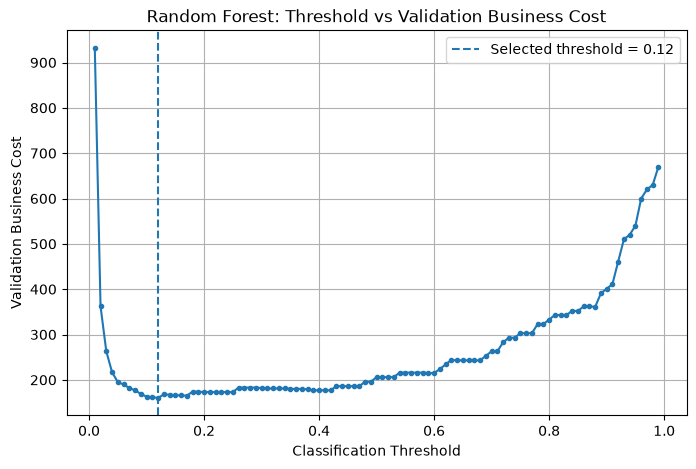

In [11]:
# ============================================================
# RF validation threshold vs business cost
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    rf_sweep["threshold"],
    rf_sweep["total_cost"],
    marker="o",
    markersize=3
)

plt.axvline(
    rf_threshold,
    linestyle="--",
    label=f"Selected threshold = {rf_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Validation Business Cost")

plt.title(
    "Random Forest: Threshold vs Validation Business Cost"
)

plt.grid(True)
plt.legend()

plt.show()

In [12]:
# ============================================================
# MLP factory
# ============================================================

INPUT_DIM = X_train_scaled.shape[1]


def make_mlp():

    model = MLPClassifier(
        input_dim=INPUT_DIM,
        hidden_dims=(64, 32),
        dropout=0.2
    )

    return model.to(device)


# ============================================================
# Standard training
# ============================================================

def train_standard(
    model,
    loader,
    criterion,
    epochs=10
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for xb, yb, _ in loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                * len(xb)
            )

        epoch_loss = (
            total_loss
            / len(loader.dataset)
        )

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {epoch_loss:.6f}"
        )


# ============================================================
# Prediction
# ============================================================

@torch.no_grad()
def predict_probs(
    model,
    loader
):

    model.eval()

    all_probabilities = []
    all_targets = []

    for xb, yb, _ in loader:

        xb = xb.to(device)

        logits = model(xb)

        probabilities = torch.sigmoid(
            logits
        )

        all_probabilities.append(
            probabilities
            .cpu()
            .numpy()
            .reshape(-1)
        )

        all_targets.append(
            yb.numpy()
        )

    probabilities = np.concatenate(
        all_probabilities
    )

    targets = np.concatenate(
        all_targets
    )

    return targets, probabilities

In [13]:
# ============================================================
# MLP + BCE
# ============================================================

print("=" * 60)
print("Training MLP + BCE")
print("=" * 60)

torch.manual_seed(SEED)

model_bce = make_mlp()

criterion_bce = nn.BCEWithLogitsLoss()

train_standard(
    model_bce,
    train_loader,
    criterion_bce,
    epochs=10
)


# ============================================================
# Validation probabilities
# ============================================================

y_val_bce, val_bce_probs = predict_probs(
    model_bce,
    val_loader
)


# ============================================================
# Test probabilities
# ============================================================

y_test_bce, test_bce_probs = predict_probs(
    model_bce,
    test_loader
)


# ============================================================
# Threshold selection using validation only
# ============================================================

bce_threshold, bce_sweep = select_threshold(
    y_val_bce,
    val_bce_probs
)

print(
    "\nBCE selected threshold:",
    bce_threshold
)


# ============================================================
# Final test evaluation
# ============================================================

bce_result = evaluate_probs(
    y_test_bce,
    test_bce_probs,
    bce_threshold,
    model_name="MLP + BCE"
)

pd.DataFrame([bce_result])

Training MLP + BCE
Epoch 1/10 - Loss: 0.061052
Epoch 2/10 - Loss: 0.004903
Epoch 3/10 - Loss: 0.004120
Epoch 4/10 - Loss: 0.003691
Epoch 5/10 - Loss: 0.003271
Epoch 6/10 - Loss: 0.003039
Epoch 7/10 - Loss: 0.002793
Epoch 8/10 - Loss: 0.002593
Epoch 9/10 - Loss: 0.002483
Epoch 10/10 - Loss: 0.002428

BCE selected threshold: 0.04


,model,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,total_cost
0,MLP + BCE,0.04,0.622222,0.857143,0.72103,0.977731,0.73556,56813,51,14,84,191.0


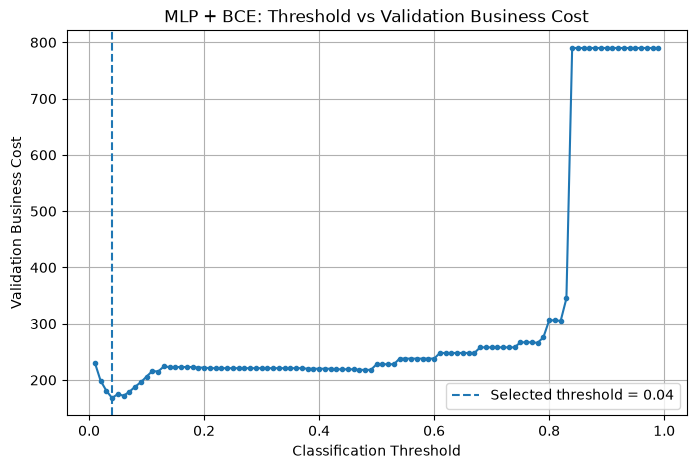

In [14]:
# ============================================================
# BCE validation threshold vs cost
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    bce_sweep["threshold"],
    bce_sweep["total_cost"],
    marker="o",
    markersize=3
)

plt.axvline(
    bce_threshold,
    linestyle="--",
    label=f"Selected threshold = {bce_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Validation Business Cost")

plt.title(
    "MLP + BCE: Threshold vs Validation Business Cost"
)

plt.grid(True)
plt.legend()

plt.show()

In [15]:
# ============================================================
# Calculate positive-class weight
# ============================================================

num_positive = int(
    (np.asarray(y_train) == 1).sum()
)

num_negative = int(
    (np.asarray(y_train) == 0).sum()
)

pos_weight_value = (
    num_negative
    / num_positive
)

print("Positive samples:", num_positive)
print("Negative samples:", num_negative)
print("pos_weight:", pos_weight_value)


# ============================================================
# Weighted BCE
# ============================================================

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)


# ============================================================
# Train weighted MLP
# ============================================================

print("=" * 60)
print("Training MLP + Weighted BCE")
print("=" * 60)

torch.manual_seed(SEED)

model_weighted = make_mlp()

criterion_weighted = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

train_standard(
    model_weighted,
    train_loader,
    criterion_weighted,
    epochs=10
)


# ============================================================
# Validation predictions
# ============================================================

y_val_weighted, val_weighted_probs = predict_probs(
    model_weighted,
    val_loader
)


# ============================================================
# Test predictions
# ============================================================

y_test_weighted, test_weighted_probs = predict_probs(
    model_weighted,
    test_loader
)


# ============================================================
# Threshold optimization
# ============================================================

weighted_threshold, weighted_sweep = select_threshold(
    y_val_weighted,
    val_weighted_probs
)

print(
    "\nWeighted BCE selected threshold:",
    weighted_threshold
)


# ============================================================
# Final test evaluation
# ============================================================

weighted_result = evaluate_probs(
    y_test_weighted,
    test_weighted_probs,
    weighted_threshold,
    model_name="MLP + Weighted BCE"
)

pd.DataFrame([weighted_result])

Positive samples: 315
Negative samples: 181961
pos_weight: 577.6539682539683
Training MLP + Weighted BCE
Epoch 1/10 - Loss: 0.538648
Epoch 2/10 - Loss: 0.279173
Epoch 3/10 - Loss: 0.249886
Epoch 4/10 - Loss: 0.209124
Epoch 5/10 - Loss: 0.192822
Epoch 6/10 - Loss: 0.179027
Epoch 7/10 - Loss: 0.171567
Epoch 8/10 - Loss: 0.153725
Epoch 9/10 - Loss: 0.182417
Epoch 10/10 - Loss: 0.117440

Weighted BCE selected threshold: 0.98


,model,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,total_cost
0,MLP + Weighted BCE,0.98,0.68,0.867347,0.762332,0.975159,0.719056,56824,40,13,85,170.0


In [16]:
# ============================================================
# Adaptive Cost-Sensitive Training
# ============================================================

def train_adaptive(
    model,
    loader,
    epochs=15,
    ema_alpha=0.9
):

    # --------------------------------------------------------
    # Existing project adaptive loss
    # --------------------------------------------------------

    criterion = AdaptiveCostSensitiveLoss(
        pos_cost=10.0,
        neg_cost=1.0,
        hardness_scale=1.0
    ).to(device)


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )


    # --------------------------------------------------------
    # One hardness value per training sample
    # --------------------------------------------------------

    hardness = torch.zeros(
        len(loader.dataset),
        dtype=torch.float32,
        device=device
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0

        for xb, yb, idx in loader:

            xb = xb.to(device)
            yb = yb.to(device)
            idx = idx.to(device)

            optimizer.zero_grad()

            # Forward pass
            logits = model(xb)

            # Adaptive loss
            loss, base_loss_det = criterion(
                logits,
                yb,
                sample_ids=idx,
                hardness=hardness
            )

            # Backpropagation
            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                * len(xb)
            )

            # ------------------------------------------------
            # Update EMA hardness
            # ------------------------------------------------

            with torch.no_grad():

                old_hardness = hardness[idx]

                new_hardness = (
                    ema_alpha * old_hardness
                    + (1.0 - ema_alpha)
                    * base_loss_det.to(device)
                )

                hardness[idx] = new_hardness


        epoch_loss = (
            total_loss
            / len(loader.dataset)
        )

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Adaptive Loss: {epoch_loss:.6f}"
        )


    return model, hardness

In [17]:
# ============================================================
# Train adaptive model
# ============================================================

print("=" * 60)
print("Training MLP + Adaptive Cost-Sensitive Loss")
print("=" * 60)

torch.manual_seed(SEED)

model_adaptive = make_mlp()

model_adaptive, final_hardness = train_adaptive(
    model_adaptive,
    train_loader,
    epochs=15,
    ema_alpha=0.9
)


# ============================================================
# Validation predictions
# ============================================================

y_val_adaptive, val_adaptive_probs = predict_probs(
    model_adaptive,
    val_loader
)


# ============================================================
# Test predictions
# ============================================================

y_test_adaptive, test_adaptive_probs = predict_probs(
    model_adaptive,
    test_loader
)


# ============================================================
# Threshold optimization
# ============================================================

adaptive_threshold, adaptive_sweep = select_threshold(
    y_val_adaptive,
    val_adaptive_probs
)

print(
    "\nAdaptive selected threshold:",
    adaptive_threshold
)


# ============================================================
# Final test evaluation
# ============================================================

adaptive_result = evaluate_probs(
    y_test_adaptive,
    test_adaptive_probs,
    adaptive_threshold,
    model_name="MLP + Adaptive Cost-Sensitive Loss"
)

pd.DataFrame([adaptive_result])

Training MLP + Adaptive Cost-Sensitive Loss
Epoch 1/15 - Adaptive Loss: 0.092602
Epoch 2/15 - Adaptive Loss: 0.032727
Epoch 3/15 - Adaptive Loss: 0.027211
Epoch 4/15 - Adaptive Loss: 0.026056
Epoch 5/15 - Adaptive Loss: 0.024927
Epoch 6/15 - Adaptive Loss: 0.021945
Epoch 7/15 - Adaptive Loss: 0.022643
Epoch 8/15 - Adaptive Loss: 0.020694
Epoch 9/15 - Adaptive Loss: 0.018929
Epoch 10/15 - Adaptive Loss: 0.019420
Epoch 11/15 - Adaptive Loss: 0.017826
Epoch 12/15 - Adaptive Loss: 0.016819
Epoch 13/15 - Adaptive Loss: 0.016971
Epoch 14/15 - Adaptive Loss: 0.015973
Epoch 15/15 - Adaptive Loss: 0.016349

Adaptive selected threshold: 0.55


,model,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,total_cost
0,MLP + Adaptive Cost-Sensitive Loss,0.55,0.551282,0.877551,0.677165,0.973736,0.801516,56794,70,12,86,190.0


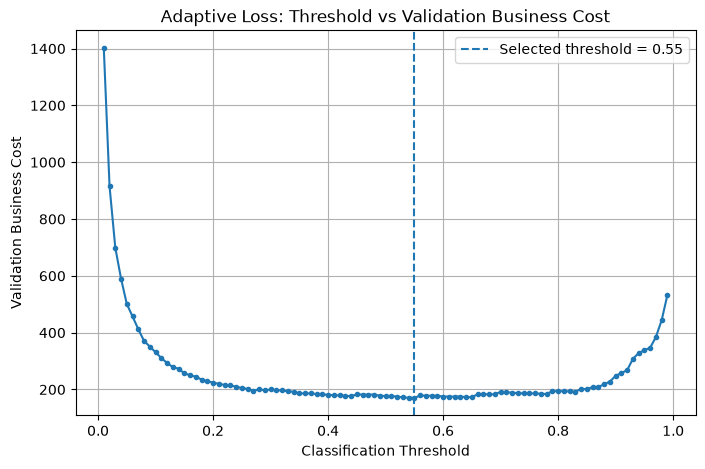

In [18]:
# ============================================================
# Adaptive model threshold vs validation business cost
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    adaptive_sweep["threshold"],
    adaptive_sweep["total_cost"],
    marker="o",
    markersize=3
)

plt.axvline(
    adaptive_threshold,
    linestyle="--",
    label=f"Selected threshold = {adaptive_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Validation Business Cost")

plt.title(
    "Adaptive Loss: Threshold vs Validation Business Cost"
)

plt.grid(True)
plt.legend()

plt.show()

In [19]:
# ============================================================
# Final comparison
# ============================================================

results = pd.DataFrame([
    rf_result,
    bce_result,
    weighted_result,
    adaptive_result
])

# Reorder columns
columns = [
    "model",
    "threshold",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "tn",
    "fp",
    "fn",
    "tp",
    "total_cost"
]

results = results[columns]

print("=" * 80)
print("FINAL TEST-SET COMPARISON")
print("=" * 80)

display(
    results.round(4)
)

FINAL TEST-SET COMPARISON


,model,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,total_cost
0,Random Forest,0.12,0.6744,0.8878,0.7665,0.9603,0.8570,56822,42,11,87,152.0
1,MLP + BCE,0.04,0.6222,0.8571,0.7210,0.9777,0.7356,56813,51,14,84,191.0
2,MLP + Weighted BCE,0.98,0.6800,0.8673,0.7623,0.9752,0.7191,56824,40,13,85,170.0
3,MLP + Adaptive Cost-Sensitive Loss,0.55,0.5513,0.8776,0.6772,0.9737,0.8015,56794,70,12,86,190.0


In [20]:
# ============================================================
# Comparison focused on business cost
# ============================================================

cost_comparison = results[
    [
        "model",
        "threshold",
        "fp",
        "fn",
        "recall",
        "precision",
        "pr_auc",
        "total_cost"
    ]
].copy()

cost_comparison = cost_comparison.sort_values(
    "total_cost"
)

display(
    cost_comparison.round(4)
)

,model,threshold,fp,fn,recall,precision,pr_auc,total_cost
0,Random Forest,0.12,42,11,0.8878,0.6744,0.8570,152.0
2,MLP + Weighted BCE,0.98,40,13,0.8673,0.6800,0.7191,170.0
3,MLP + Adaptive Cost-Sensitive Loss,0.55,70,12,0.8776,0.5513,0.8015,190.0
1,MLP + BCE,0.04,51,14,0.8571,0.6222,0.7356,191.0


In [21]:
# ============================================================
# Adaptive vs BCE comparison
# ============================================================

bce_cost = float(
    results.loc[
        results["model"] == "MLP + BCE",
        "total_cost"
    ].iloc[0]
)

adaptive_cost = float(
    results.loc[
        results["model"] == "MLP + Adaptive Cost-Sensitive Loss",
        "total_cost"
    ].iloc[0]
)

bce_fn = int(
    results.loc[
        results["model"] == "MLP + BCE",
        "fn"
    ].iloc[0]
)

adaptive_fn = int(
    results.loc[
        results["model"] == "MLP + Adaptive Cost-Sensitive Loss",
        "fn"
    ].iloc[0]
)

bce_fp = int(
    results.loc[
        results["model"] == "MLP + BCE",
        "fp"
    ].iloc[0]
)

adaptive_fp = int(
    results.loc[
        results["model"] == "MLP + Adaptive Cost-Sensitive Loss",
        "fp"
    ].iloc[0]
)


print("==============================================")
print("ADAPTIVE LOSS vs BCE")
print("==============================================")

print(f"BCE total cost:       {bce_cost:.0f}")
print(f"Adaptive total cost:  {adaptive_cost:.0f}")

print()

print(f"BCE false negatives:       {bce_fn}")
print(f"Adaptive false negatives:  {adaptive_fn}")

print()

print(f"BCE false positives:       {bce_fp}")
print(f"Adaptive false positives:  {adaptive_fp}")


if bce_cost != 0:

    cost_difference_pct = (
        (bce_cost - adaptive_cost)
        / bce_cost
    ) * 100

    print()

    print(
        f"Cost difference "
        f"(BCE baseline): "
        f"{cost_difference_pct:.2f}%"
    )


if bce_fn != 0:

    fn_difference_pct = (
        (bce_fn - adaptive_fn)
        / bce_fn
    ) * 100

    print(
        f"False-negative difference "
        f"(BCE baseline): "
        f"{fn_difference_pct:.2f}%"
    )

ADAPTIVE LOSS vs BCE
BCE total cost:       191
Adaptive total cost:  190

BCE false negatives:       14
Adaptive false negatives:  12

BCE false positives:       51
Adaptive false positives:  70

Cost difference (BCE baseline): 0.52%
False-negative difference (BCE baseline): 14.29%


In [22]:
# ============================================================
# Adaptive vs Random Forest
# ============================================================

rf_cost = float(
    results.loc[
        results["model"] == "Random Forest",
        "total_cost"
    ].iloc[0]
)

adaptive_cost = float(
    results.loc[
        results["model"] == "MLP + Adaptive Cost-Sensitive Loss",
        "total_cost"
    ].iloc[0]
)

rf_fn = int(
    results.loc[
        results["model"] == "Random Forest",
        "fn"
    ].iloc[0]
)

adaptive_fn = int(
    results.loc[
        results["model"] == "MLP + Adaptive Cost-Sensitive Loss",
        "fn"
    ].iloc[0]
)


print("==============================================")
print("ADAPTIVE LOSS vs RANDOM FOREST")
print("==============================================")

print(f"RF total cost:       {rf_cost:.0f}")
print(f"Adaptive total cost: {adaptive_cost:.0f}")

print()

print(f"RF false negatives:       {rf_fn}")
print(f"Adaptive false negatives: {adaptive_fn}")

if rf_cost != 0:

    cost_difference_pct = (
        (rf_cost - adaptive_cost)
        / rf_cost
    ) * 100

    print()

    print(
        f"Cost difference "
        f"(RF baseline): "
        f"{cost_difference_pct:.2f}%"
    )

if rf_fn != 0:

    fn_difference_pct = (
        (rf_fn - adaptive_fn)
        / rf_fn
    ) * 100

    print(
        f"False-negative difference "
        f"(RF baseline): "
        f"{fn_difference_pct:.2f}%"
    )

ADAPTIVE LOSS vs RANDOM FOREST
RF total cost:       152
Adaptive total cost: 190

RF false negatives:       11
Adaptive false negatives: 12

Cost difference (RF baseline): -25.00%
False-negative difference (RF baseline): -9.09%


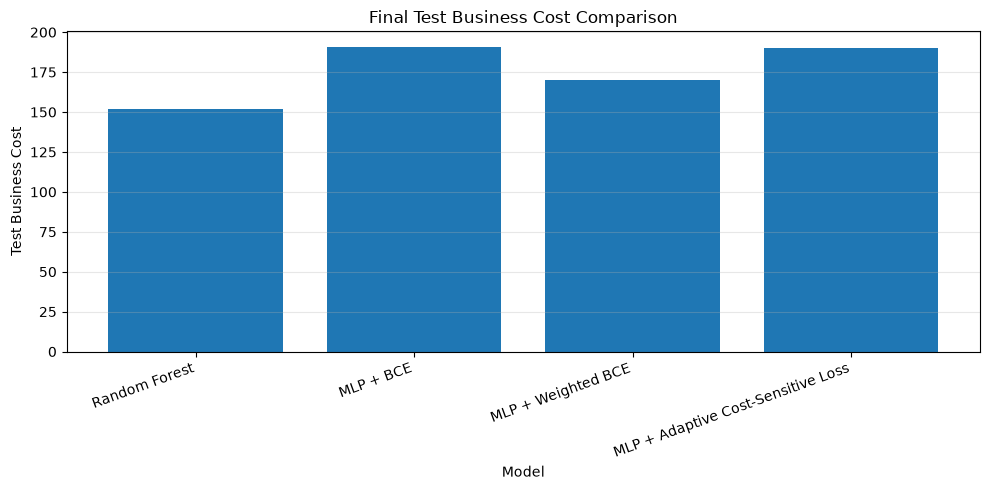

In [23]:
# ============================================================
# Business cost comparison
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    results["model"],
    results["total_cost"]
)

plt.ylabel("Test Business Cost")

plt.xlabel("Model")

plt.title(
    "Final Test Business Cost Comparison"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

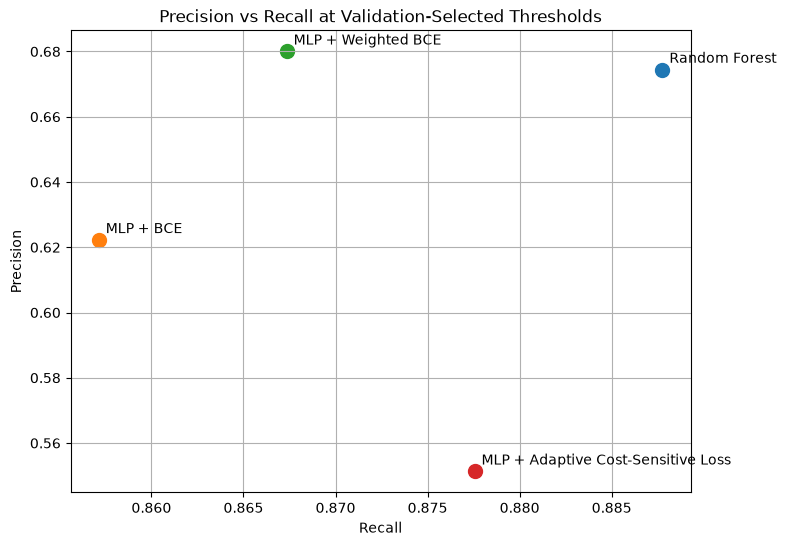

In [24]:
# ============================================================
# Precision vs Recall
# ============================================================

plt.figure(figsize=(8, 6))

for _, row in results.iterrows():

    plt.scatter(
        row["recall"],
        row["precision"],
        s=100
    )

    plt.annotate(
        row["model"],
        (
            row["recall"],
            row["precision"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision vs Recall at Validation-Selected Thresholds"
)

plt.grid(True)

plt.show()

Hardness statistics
count    182276.000000
mean          0.005739
std           0.066890
min           0.000000
25%           0.000237
50%           0.000819
75%           0.003473
max           6.782342
dtype: float64


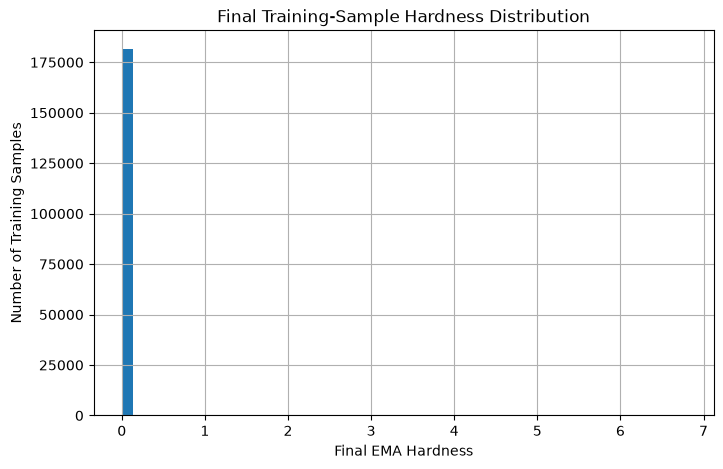

In [25]:
# ============================================================
# Hardness distribution
# ============================================================

hardness_values = (
    final_hardness
    .detach()
    .cpu()
    .numpy()
)

print("Hardness statistics")
print("=" * 50)

print(
    pd.Series(hardness_values).describe()
)


# ============================================================
# Plot hardness distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    hardness_values,
    bins=50
)

plt.xlabel("Final EMA Hardness")
plt.ylabel("Number of Training Samples")

plt.title(
    "Final Training-Sample Hardness Distribution"
)

plt.grid(True)

plt.show()

In [26]:
# ============================================================
# Hardness by class
# ============================================================

hardness_df = pd.DataFrame({
    "label": np.asarray(y_train).astype(int),
    "hardness": hardness_values
})

print("Hardness statistics by class")
print("=" * 60)

display(
    hardness_df
    .groupby("label")["hardness"]
    .describe()
)

Hardness statistics by class


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,181961.0,0.005165,0.056609,0.00000,0.000236,0.000816,0.003444,6.782342
1,315.0,0.336944,0.793763,0.00014,0.015694,0.054447,0.129224,6.608580


In [27]:
# ============================================================
# Save final comparison
# ============================================================

experiments_dir = os.path.join(
    PROJECT_ROOT,
    "experiments"
)

os.makedirs(
    experiments_dir,
    exist_ok=True
)

results_path = os.path.join(
    experiments_dir,
    "threshold_vs_loss_comparison.csv"
)

results.to_csv(
    results_path,
    index=False
)

print(
    "Saved results to:"
)

print(results_path)

Saved results to:
C:\Users\Tausif\Desktop\adaptive-cost-sensitive-loss\adaptive-cost-sensitive-loss\experiments\threshold_vs_loss_comparison.csv


In [28]:
# ============================================================
# Save threshold sweeps
# ============================================================

rf_sweep.to_csv(
    os.path.join(
        experiments_dir,
        "rf_threshold_sweep.csv"
    ),
    index=False
)

bce_sweep.to_csv(
    os.path.join(
        experiments_dir,
        "bce_threshold_sweep.csv"
    ),
    index=False
)

weighted_sweep.to_csv(
    os.path.join(
        experiments_dir,
        "weighted_bce_threshold_sweep.csv"
    ),
    index=False
)

adaptive_sweep.to_csv(
    os.path.join(
        experiments_dir,
        "adaptive_threshold_sweep.csv"
    ),
    index=False
)

print("Threshold sweep files saved.")

Threshold sweep files saved.


In [29]:
# ============================================================
# Experiment summary
# ============================================================

print()
print("=" * 80)
print("EXPERIMENT 05 SUMMARY")
print("=" * 80)

print()
print("Dataset:")
print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples:       {len(X_test):,}")

print()
print("Cost policy:")
print(f"False Negative Cost = {FN_COST}")
print(f"False Positive Cost = {FP_COST}")

print()
print("Selected thresholds:")

for _, row in results.iterrows():

    print(
        f"{row['model']:<40} "
        f"{row['threshold']:.2f}"
    )

print()
print("Final test metrics:")

display(
    results[
        [
            "model",
            "threshold",
            "precision",
            "recall",
            "f1",
            "pr_auc",
            "fp",
            "fn",
            "total_cost"
        ]
    ].round(4)
)

print()
print("=" * 80)
print("Experiment complete.")
print("=" * 80)


EXPERIMENT 05 SUMMARY

Dataset:
Training samples:   182,276
Validation samples: 45,569
Test samples:       56,962

Cost policy:
False Negative Cost = 10.0
False Positive Cost = 1.0

Selected thresholds:
Random Forest                            0.12
MLP + BCE                                0.04
MLP + Weighted BCE                       0.98
MLP + Adaptive Cost-Sensitive Loss       0.55

Final test metrics:


,model,threshold,precision,recall,f1,pr_auc,fp,fn,total_cost
0,Random Forest,0.12,0.6744,0.8878,0.7665,0.8570,42,11,152.0
1,MLP + BCE,0.04,0.6222,0.8571,0.7210,0.7356,51,14,191.0
2,MLP + Weighted BCE,0.98,0.6800,0.8673,0.7623,0.7191,40,13,170.0
3,MLP + Adaptive Cost-Sensitive Loss,0.55,0.5513,0.8776,0.6772,0.8015,70,12,190.0



Experiment complete.
